# HR Employee Attrition Analysis

---



# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load Dataset

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Dataset Overview

print("Rows, Columns:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Rows, Columns: (1470, 35)

Columns:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [4]:
# Data Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Missing Values Check

In [5]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


# Basic Statistics

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Shows mean, min, max, std etc. for numeric columns.

# Attrition Distribution

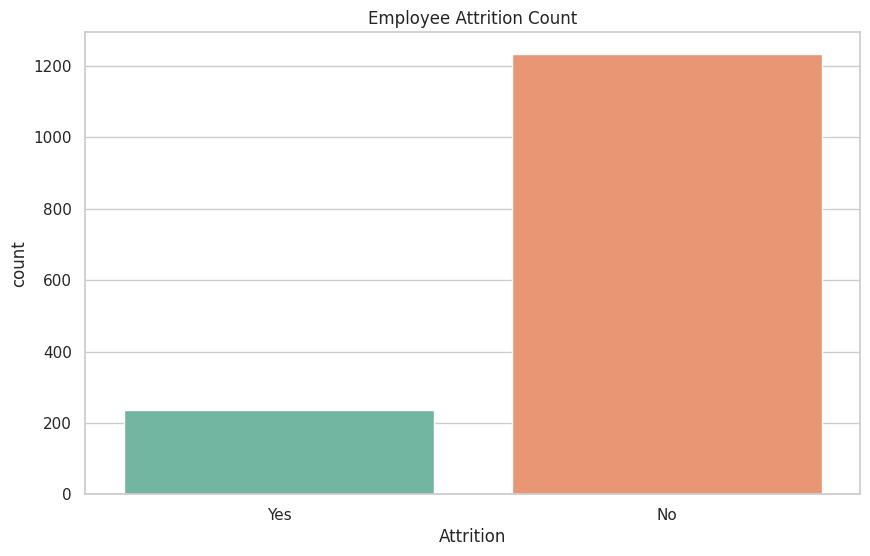

In [7]:
sns.countplot(x="Attrition", data=df, palette="Set2")
plt.title("Employee Attrition Count")
plt.show()

See how many employees left (Yes) vs stayed (No).

# Attrition Percentage

In [8]:
attrition_rate = df["Attrition"].value_counts(normalize=True) * 100
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Find percentage of attrition.

# Salary Impact on Attrition

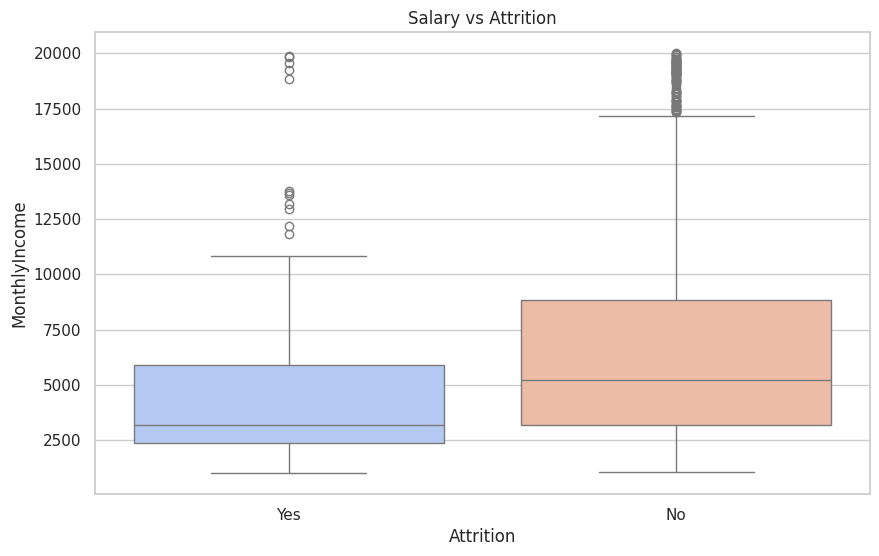

In [9]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, palette="coolwarm")
plt.title("Salary vs Attrition")
plt.show()

Compare salaries of employees who left vs stayed.

# Department Trends

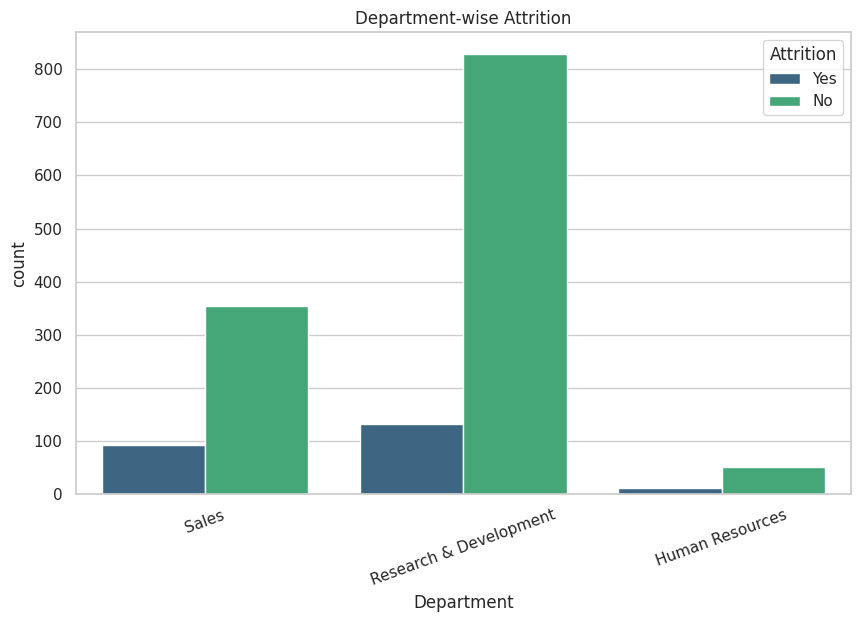

In [10]:
sns.countplot(x="Department", hue="Attrition", data=df, palette="viridis")
plt.title("Department-wise Attrition")
plt.xticks(rotation=20)
plt.show()

Find which department has highest attrition.

# Overtime Impact

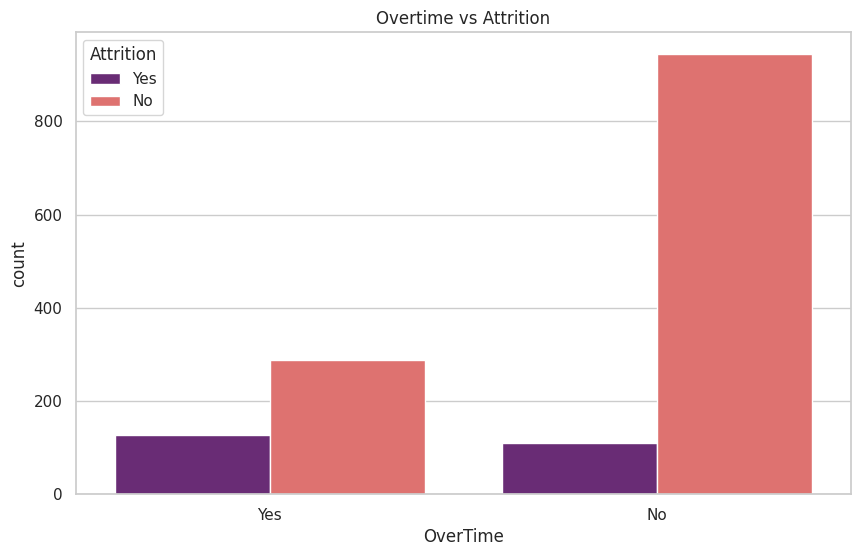

In [11]:
sns.countplot(x="OverTime", hue="Attrition", data=df, palette="magma")
plt.title("Overtime vs Attrition")
plt.show()

Employees doing overtime may leave more often.

# Job Satisfaction vs Attrition

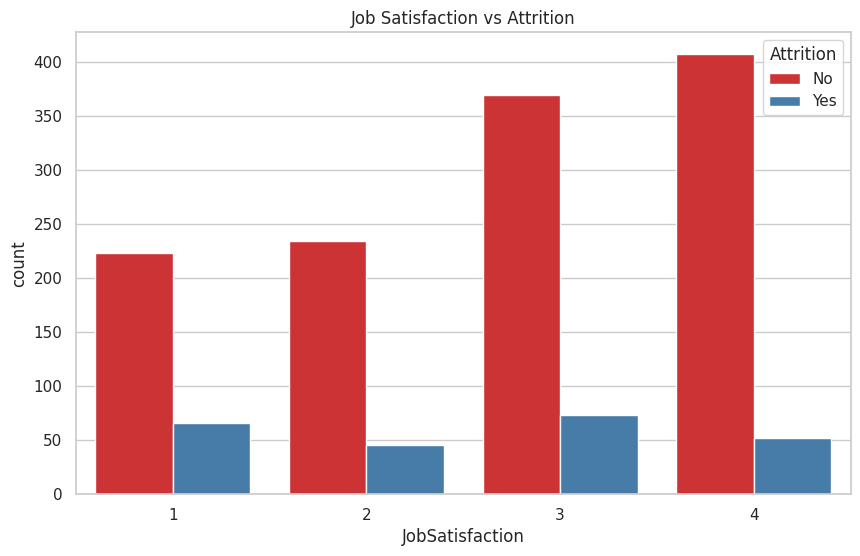

In [12]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df, palette="Set1")
plt.title("Job Satisfaction vs Attrition")
plt.show()

Low job satisfaction often increases attrition.

# Work Life Balance vs Attrition

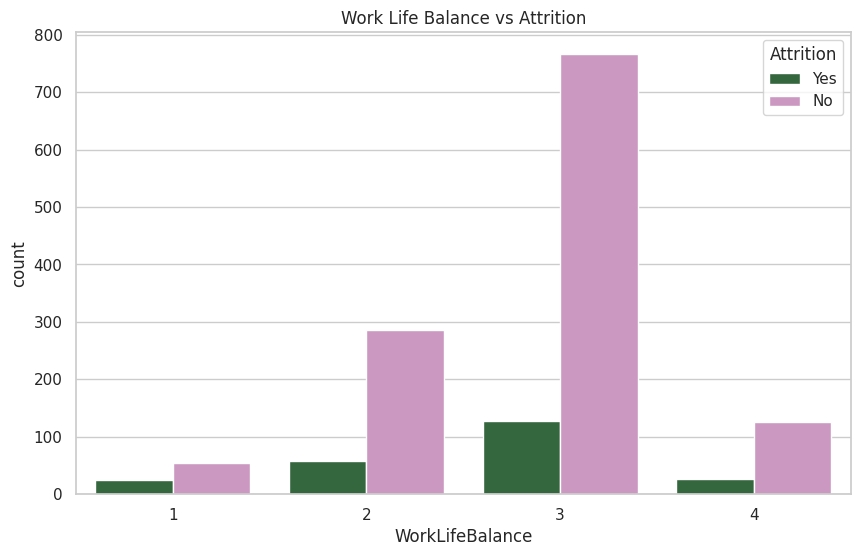

In [13]:
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df, palette="cubehelix")
plt.title("Work Life Balance vs Attrition")
plt.show()

Check if poor balance causes resignations.

# Age Distribution

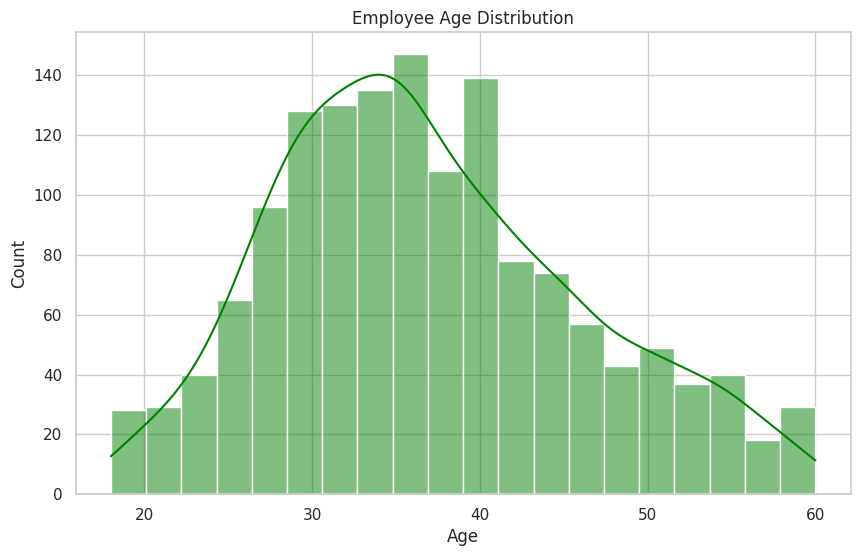

In [14]:
sns.histplot(df["Age"], bins=20, kde=True, color="green")
plt.title("Employee Age Distribution")
plt.show()

Shows age range of employees.

# Years at Company vs Attrition

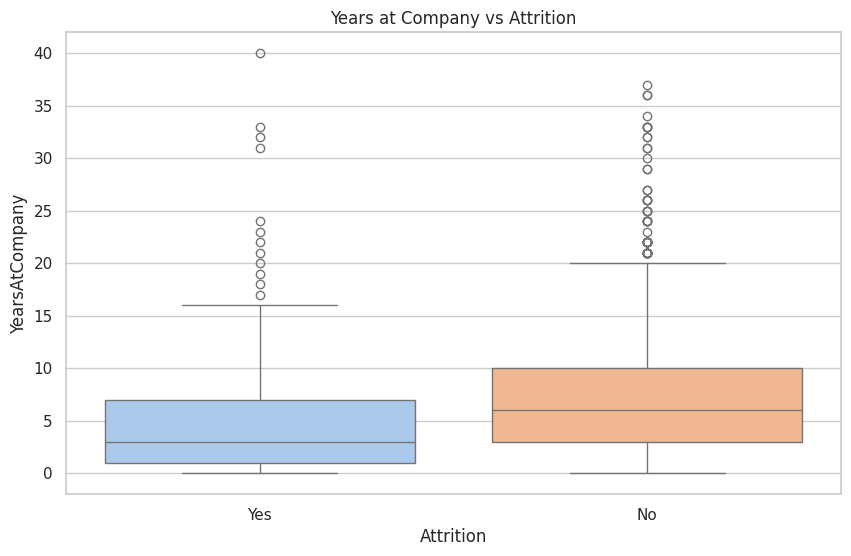

In [15]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df, palette="pastel")
plt.title("Years at Company vs Attrition")
plt.show()

Check if new employees leave more.

# Correlation Heatmap

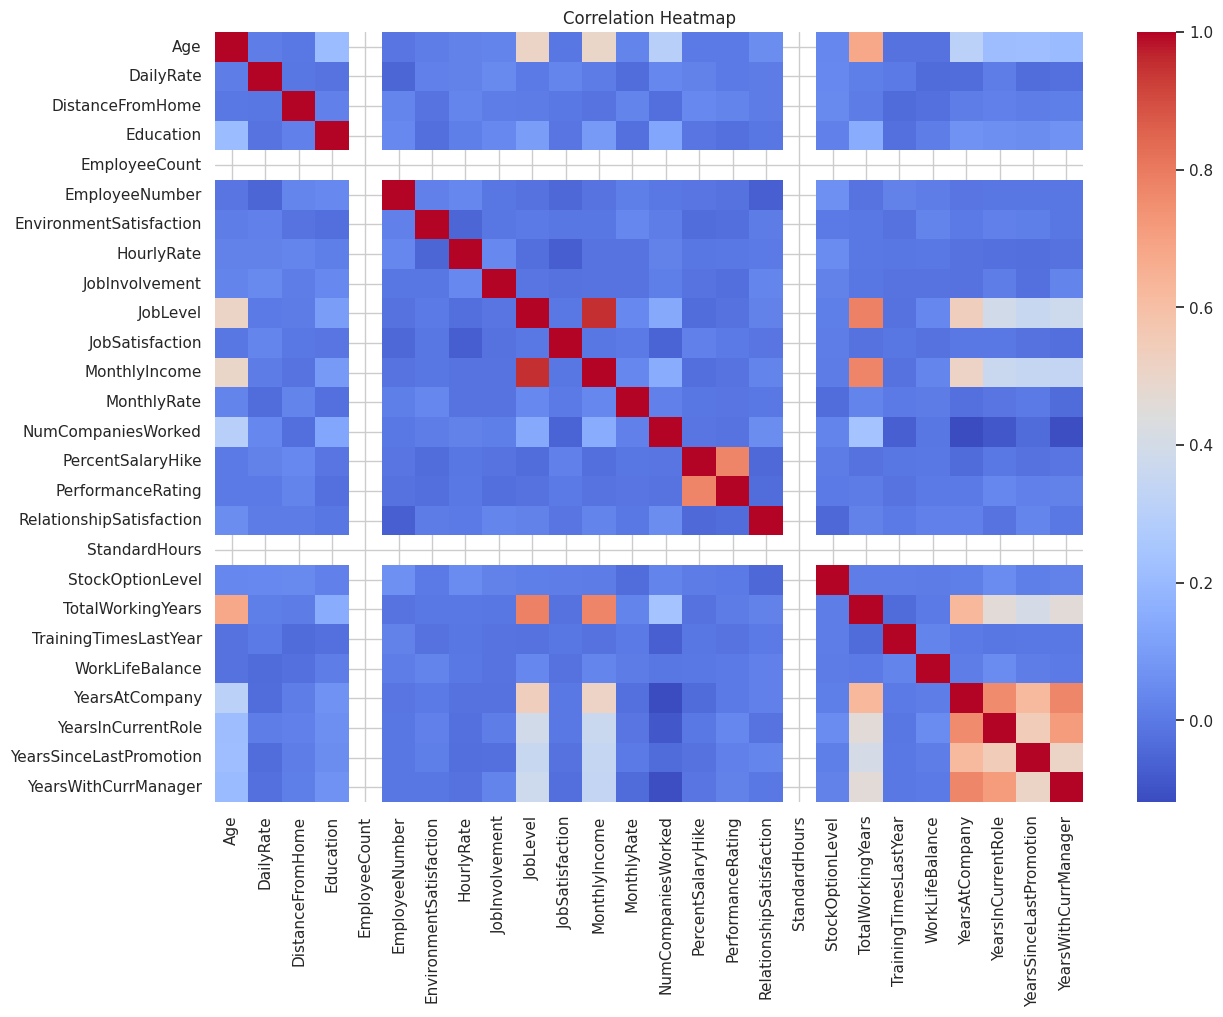

In [16]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Shows relationships between numerical columns.

# Top Reasons Analysis

In [17]:
left_emp = df[df["Attrition"] == "Yes"]

print("Average Salary of Employees Who Left:", left_emp["MonthlyIncome"].mean())
print("Most Common Department:", left_emp["Department"].mode()[0])
print("Most Common Overtime:", left_emp["OverTime"].mode()[0])

Average Salary of Employees Who Left: 4787.0928270042195
Most Common Department: Research & Development
Most Common Overtime: Yes


Quick insights for employees who resigned.

---

# **Encode Data for Machine Learning**

---



In [22]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

df_ml.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Convert text columns into numeric values.

In [23]:
# Train Test Split

from sklearn.model_selection import train_test_split

X = df_ml.drop("Attrition", axis=1)
y = df_ml["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.891156462585034

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94       255
           1       0.82      0.23      0.36        39

    accuracy                           0.89       294
   macro avg       0.86      0.61      0.65       294
weighted avg       0.88      0.89      0.86       294



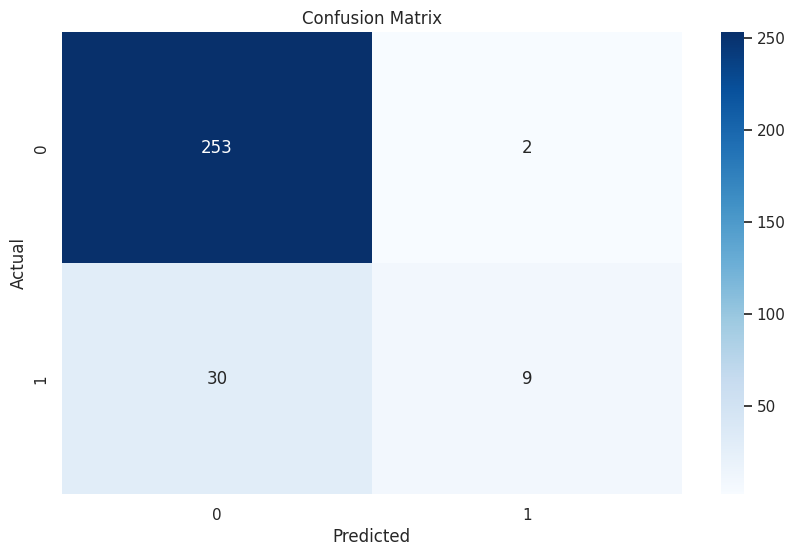

In [27]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Final Business Insights

In [28]:
print("📌 Key Insights:")
print("1. Employees with overtime are more likely to leave.")
print("2. Lower salary employees show higher attrition.")
print("3. Some departments have higher turnover.")
print("4. Low job satisfaction impacts retention.")
print("5. ML model can help HR predict resignations early.")

📌 Key Insights:
1. Employees with overtime are more likely to leave.
2. Lower salary employees show higher attrition.
3. Some departments have higher turnover.
4. Low job satisfaction impacts retention.
5. ML model can help HR predict resignations early.
